# Exploring the AnnData Object
This notebook walks through the key components of an AnnData object using a preprocessed PBMC dataset.

## 1. Install dependencies

In [1]:
!pip install anndata scanpy pooch -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 65.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.


## 2. Import libraries

In [2]:
import anndata
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import pooch

## 3. Download and load the PBMC dataset (~100 MB)

In [3]:
datapath = pooch.retrieve(
    path=pooch.os_cache('scverse_tutorials'),
    url='https://exampledata.scverse.org/tutorials/scverse-getting-started-anndata-pbmc3k_processed.h5ad',
    known_hash='md5:b80deb0997f96b45d06f19c694e46243',
)
adata = anndata.read_h5ad(datapath)
adata

AnnData object with n_obs × n_vars = 2638 × 11505
    obs: 'n_genes', 'percent_mito', 'n_counts', 'louvain_cell_types'
    var: 'gene_names', 'n_cells', 'gene_ids'
    uns: 'louvain', 'louvain_colors', 'pca'
    obsm: 'X_pca', 'X_tsne', 'X_umap'
    layers: 'raw'
    obsp: 'distances_all'

## 4. The active data matrix `adata.X`

In [4]:
print('Data matrix:')
print(adata.X)
print('\nNon-zero values (first 10):')
print(adata.X.data[:10])
print('\nFraction of non-zero entries:')
print(adata.X.nnz / np.prod(adata.X.shape))

Data matrix:
<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 2076576 stored elements and shape (2638, 11505)>
  Coords	Values
  (0, 19)	0.6496620774269104
  (0, 52)	0.6496620774269104
  (0, 58)	1.0402015447616577
  (0, 118)	0.6496620774269104
  (0, 131)	0.6496620774269104
  (0, 146)	0.6496620774269104
  (0, 147)	0.6496620774269104
  (0, 180)	3.6509344577789307
  (0, 181)	0.6496620774269104
  (0, 182)	0.6496620774269104
  (0, 208)	1.0402015447616577
  (0, 210)	1.7181968688964844
  (0, 263)	0.6496620774269104
  (0, 270)	0.6496620774269104
  (0, 291)	0.6496620774269104
  (0, 313)	0.6496620774269104
  (0, 324)	0.6496620774269104
  (0, 336)	0.6496620774269104
  (0, 357)	1.0402015447616577
  (0, 362)	0.6496620774269104
  (0, 380)	2.6894383430480957
  (0, 394)	0.6496620774269104
  (0, 402)	0.6496620774269104
  (0, 411)	0.6496620774269104
  (0, 418)	0.6496620774269104
  :	:
  (2637, 11103)	0.7506172060966492
  (2637, 11191)	0.7506172060966492
  (2637, 11210)	0.7506172060966492
  

## 5. Additional data layers

In [5]:
print('Available layers:', adata.layers)
print('\nRaw layer (first 5 values):')
print(adata.layers['raw'].data[:5])

# Add a counts-per-million layer
adata.layers['counts_per_million'] = adata.layers['raw'].copy()
sc.pp.normalize_total(adata, target_sum=10**6, layer='counts_per_million')
print('\nLayers after adding CPM:', adata.layers)

Available layers: Layers with keys: raw

Raw layer (first 5 values):
[1 1 2 1 1]

Layers after adding CPM: Layers with keys: raw, counts_per_million


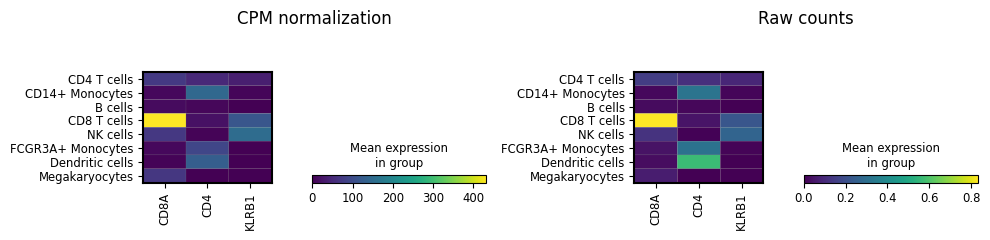

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 2.5))
genes_of_interest = ['CD8A', 'CD4', 'KLRB1']

sc.pl.matrixplot(adata, groupby='louvain_cell_types', var_names=genes_of_interest,
                 layer='counts_per_million', ax=ax1, show=False)
ax1.set_title('CPM normalization')

sc.pl.matrixplot(adata, groupby='louvain_cell_types', var_names=genes_of_interest,
                 layer='raw', ax=ax2, show=False)
ax2.set_title('Raw counts')
plt.tight_layout()
plt.show()

## 6. Cell annotations in `adata.obs`

In [7]:
print('obs columns:', adata.obs.keys().tolist())
adata.obs.head()

obs columns: ['n_genes', 'percent_mito', 'n_counts', 'louvain_cell_types']


,n_genes,percent_mito,n_counts,louvain_cell_types
cell_barcode,,,,
AAACATACAACCAC-1,781,0.030178,2419.0,CD4 T cells
AAACATTGAGCTAC-1,1352,0.037936,4903.0,B cells
AAACATTGATCAGC-1,1131,0.008897,3147.0,CD4 T cells
AAACCGTGCTTCCG-1,960,0.017431,2639.0,CD14+ Monocytes
AAACCGTGTATGCG-1,522,0.012245,980.0,NK cells


In [8]:
print('Number of B cells:', sum(adata.obs['louvain_cell_types'] == 'B cells'))

# Add a low-quality cell flag
adata.obs['is_low_quality'] = adata.obs['percent_mito'] > 0.03
adata.obs.head()

Number of B cells: 342


,n_genes,percent_mito,n_counts,louvain_cell_types,is_low_quality
cell_barcode,,,,,
AAACATACAACCAC-1,781,0.030178,2419.0,CD4 T cells,True
AAACATTGAGCTAC-1,1352,0.037936,4903.0,B cells,True
AAACATTGATCAGC-1,1131,0.008897,3147.0,CD4 T cells,False
AAACCGTGCTTCCG-1,960,0.017431,2639.0,CD14+ Monocytes,False
AAACCGTGTATGCG-1,522,0.012245,980.0,NK cells,False


## 7. Gene annotations in `adata.var`

In [9]:
adata.var.head()

,gene_names,n_cells,gene_ids
gene_names,,,
LINC00115,LINC00115,18,ENSG00000225880
NOC2L,NOC2L,258,ENSG00000188976
KLHL17,KLHL17,9,ENSG00000187961
PLEKHN1,PLEKHN1,7,ENSG00000187583
HES4,HES4,145,ENSG00000188290


## 8. Shared indexing: `obs_names` and `var_names`

In [10]:
print('Cell barcodes (first 5):')
print(adata.obs_names[:5])
print('\nGene names (first 5):')
print(adata.var_names[:5])

# Switch to Ensembl IDs
adata.var_names = adata.var['gene_ids']
print('\nvar with Ensembl ID index:')
print(adata.var.head())

# Switch back
adata.var_names = adata.var['gene_names']
print('\nvar back to gene names:')
print(adata.var.head())

Cell barcodes (first 5):
Index(['AAACATACAACCAC-1', 'AAACATTGAGCTAC-1', 'AAACATTGATCAGC-1',
       'AAACCGTGCTTCCG-1', 'AAACCGTGTATGCG-1'],
      dtype='object', name='cell_barcode')

Gene names (first 5):
Index(['LINC00115', 'NOC2L', 'KLHL17', 'PLEKHN1', 'HES4'], dtype='object', name='gene_names')

var with Ensembl ID index:
                gene_names  n_cells         gene_ids
gene_ids                                            
ENSG00000225880  LINC00115       18  ENSG00000225880
ENSG00000188976      NOC2L      258  ENSG00000188976
ENSG00000187961     KLHL17        9  ENSG00000187961
ENSG00000187583    PLEKHN1        7  ENSG00000187583
ENSG00000188290       HES4      145  ENSG00000188290

var back to gene names:
           gene_names  n_cells         gene_ids
gene_names                                     
LINC00115   LINC00115       18  ENSG00000225880
NOC2L           NOC2L      258  ENSG00000188976
KLHL17         KLHL17        9  ENSG00000187961
PLEKHN1       PLEKHN1        7  ENSG

## 9. Subsetting AnnData objects

In [11]:
adata_small = adata[:5, ['LYZ', 'FOS', 'MALAT1']]
print('Subsetted shape:', adata_small.shape)
print('\nActive data (log-normalized):')
print(adata_small.X.toarray())
print('\nRaw layer:')
print(adata_small.layers['raw'].toarray())
print('\nCell annotations:')
print(adata_small.obs)
print('\nGene annotations:')
print(adata_small.var)

Subsetted shape: (5, 3)

Active data (log-normalized):
[[0.6496621  2.4036813  3.8249342 ]
 [0.8553989  0.64266497 4.174533  ]
 [0.878057   2.8014445  4.7918878 ]
 [3.0494576  1.6464083  2.3237872 ]
 [0.         0.         3.923651  ]]

Raw layer:
[[  1  11  49]
 [  3   2 142]
 [  2  22 170]
 [ 24   5  11]
 [  0   0  22]]

Cell annotations:
                  n_genes  percent_mito  n_counts louvain_cell_types  \
cell_barcode                                                           
AAACATACAACCAC-1      781      0.030178    2419.0        CD4 T cells   
AAACATTGAGCTAC-1     1352      0.037936    4903.0            B cells   
AAACATTGATCAGC-1     1131      0.008897    3147.0        CD4 T cells   
AAACCGTGCTTCCG-1      960      0.017431    2639.0    CD14+ Monocytes   
AAACCGTGTATGCG-1      522      0.012245     980.0           NK cells   

                  is_low_quality  
cell_barcode                      
AAACATACAACCAC-1            True  
AAACATTGAGCTAC-1            True  
AAACATTGATCA

In [12]:
# Boolean subsetting: keep only high-quality cells
adata_hq = adata[~adata.obs['is_low_quality'], :]
print('High-quality cells:', adata_hq.n_obs)
adata_hq.obs.head()

High-quality cells: 2257


,n_genes,percent_mito,n_counts,louvain_cell_types,is_low_quality
cell_barcode,,,,,
AAACATTGATCAGC-1,1131,0.008897,3147.0,CD4 T cells,False
AAACCGTGCTTCCG-1,960,0.017431,2639.0,CD14+ Monocytes,False
AAACCGTGTATGCG-1,522,0.012245,980.0,NK cells,False
AAACGCACTGGTAC-1,782,0.016644,2163.0,CD8 T cells,False
AAACGCTGTAGCCA-1,533,0.011765,1275.0,CD4 T cells,False


## 10. Multidimensional embeddings in `adata.obsm`

In [13]:
for key in adata.obsm:
    print(key, adata.obsm[key].shape)

X_pca (2638, 50)
X_tsne (2638, 2)
X_umap (2638, 2)


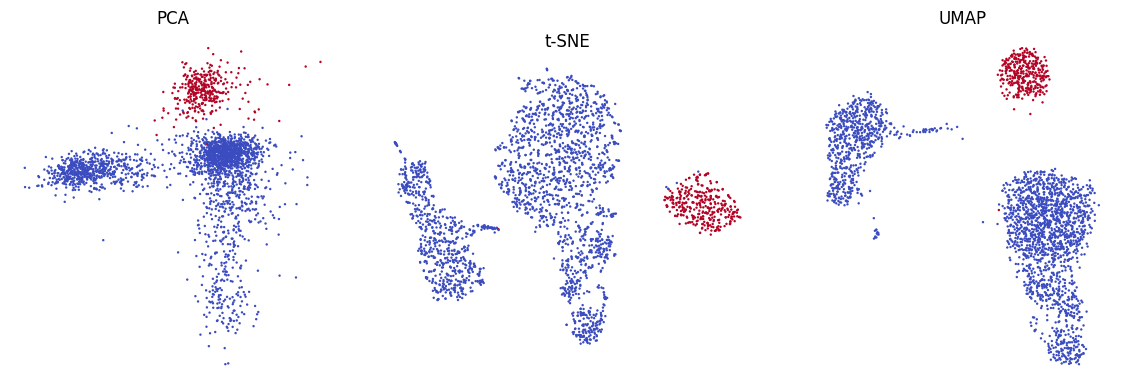

In [14]:
plt.figure(figsize=(12, 4))
for i, (key, title) in enumerate([('X_pca', 'PCA'), ('X_tsne', 't-SNE'), ('X_umap', 'UMAP')]):
    plt.subplot(1, 3, i + 1)
    plt.scatter(
        x=adata.obsm[key][:, 0],
        y=adata.obsm[key][:, 1],
        c=adata.obs['louvain_cell_types'] == 'B cells',
        s=3, linewidth=0, cmap='coolwarm'
    )
    plt.title(title)
    plt.axis('off')
    plt.gca().set_aspect('equal')
plt.tight_layout()
plt.show()

## 11. Cell-cell distances in `adata.obsp`

In [15]:
print('obsp keys:', list(adata.obsp.keys()))
print('Distance matrix shape:', adata.obsp['distances_all'].shape)

obsp keys: ['distances_all']
Distance matrix shape: (2638, 2638)


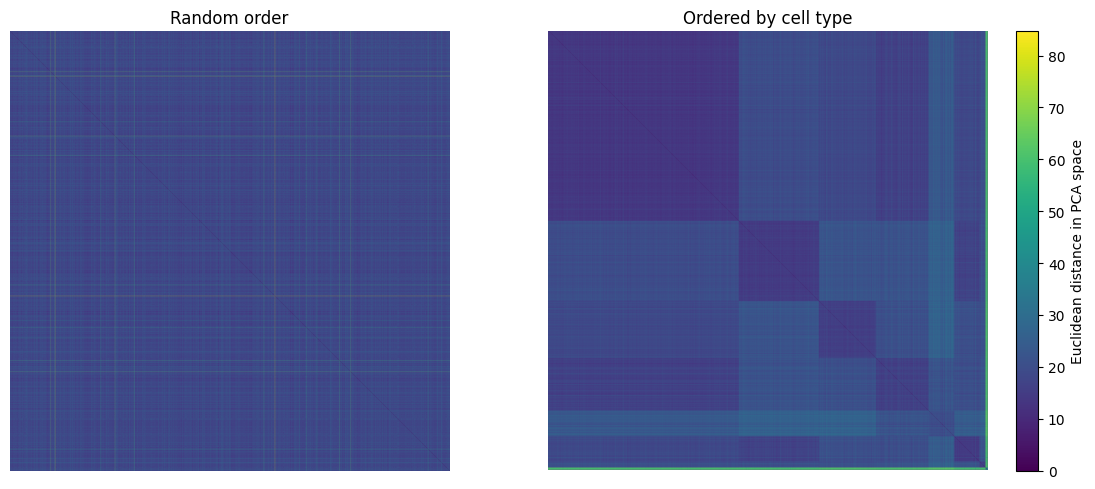

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.imshow(adata.obsp['distances_all'])
ax1.set_title('Random order')
ax1.axis('off')

reorder = np.argsort(adata.obs['louvain_cell_types'])
im = ax2.imshow(adata[reorder, :].obsp['distances_all'])
ax2.set_title('Ordered by cell type')
ax2.axis('off')

plt.colorbar(im, ax=ax2, label='Euclidean distance in PCA space')
plt.tight_layout()
plt.show()

## 12. Unstructured metadata in `adata.uns`

In [17]:
print('uns keys:', list(adata.uns.keys()))
print('\nLouvain params:', adata.uns['louvain'])
print('\nCluster colors:', adata.uns['louvain_colors'])
print('\nPCA variance (first 5):', adata.uns['pca']['variance'][:5])

uns keys: ['louvain', 'louvain_colors', 'pca']

Louvain params: {'params': {'random_state': array([0]), 'resolution': array([1])}}

Cluster colors: ['#1f77b4' '#ff7f0e' '#2ca02c' '#d62728' '#9467bd' '#8c564b' '#e377c2'
 '#bcbd22']

PCA variance (first 5): [32.11044   18.718647  15.607319  13.235274   4.8012376]


## 13. Views vs. copies

In [18]:
adata_view = adata[:5, 5:10]
print('Is a view:', adata_view.is_view)
print('\nView data:')
print(adata_view.X.toarray())

# Modify parent - change propagates to view
adata.X[0, 7] = 99
print('\nView after modifying parent (99 should appear):')
print(adata_view.X.toarray())

Is a view: True

View data:
[[0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.64266497 0.        ]
 [0.532456   0.         0.         0.         0.        ]
 [2.1446393  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.        ]]

View after modifying parent (99 should appear):
[[ 0.          0.         99.          0.          0.        ]
 [ 0.          0.          0.          0.64266497  0.        ]
 [ 0.532456    0.          0.          0.          0.        ]
 [ 2.1446393   0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.        ]]


/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


In [19]:
# Make a copy - independent from parent
adata_copy = adata_view.copy()
print('Copy is a proper AnnData:', not adata_copy.is_view)

adata.X[0, 8] = 98
print('\nParent X[0, 5:10]:')
print(adata.X[:1, 5:10].toarray())
print('\nCopy X - should NOT have 98:')
print(adata_copy.X.toarray())

Copy is a proper AnnData: True

Parent X[0, 5:10]:
[[ 0.  0. 99. 98.  0.]]

Copy X - should NOT have 98:
[[ 0.          0.         99.          0.          0.        ]
 [ 0.          0.          0.          0.64266497  0.        ]
 [ 0.532456    0.          0.          0.          0.        ]
 [ 2.1446393   0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.        ]]
